<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/10_long_short_term_memory_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Long Short-Term Memory (LSTM)

Recurrent Neural Networks (RNNs) can process sequential data, but they often struggle to remember information from earlier parts of long sequences. This is mainly due to the vanishing gradient problem, where important information gradually fades during training.

Long Short-Term Memory (LSTM) networks solve this issue by introducing a memory cell and three gating mechanisms: the Forget Gate, Input Gate, and Output Gate. These gates control which information should be forgotten, stored, and passed to the next time step.

Because of this design, LSTMs can capture long-term dependencies in sequential data and are widely used in tasks such as sentiment analysis, language modeling, machine translation, speech recognition, and time-series forecasting.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sentences = [

    "I love machine learning",

    "Deep learning is powerful",

    "Artificial intelligence is amazing",

    "Natural language processing is interesting"

]

In [3]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(

    sequences,

    padding="post"

)

print(padded_sequences)

[[ 3  4  5  2  0]
 [ 6  2  1  7  0]
 [ 8  9  1 10  0]
 [11 12 13  1 14]]


In [4]:
labels = np.array([1,1,0,0])

In [5]:
model = Sequential([

    Embedding(

        input_dim=100,

        output_dim=16,

        input_length=padded_sequences.shape[1]

    ),

    LSTM(32),

    Dense(

        1,

        activation="sigmoid"

    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [8]:
history = model.fit(

    padded_sequences,

    labels,

    epochs=10,

    verbose=1

)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6926
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.6918
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.6910
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.6902
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.6893
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.6884
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.6874
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.6864
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.6853
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.6842


In [9]:
predictions = model.predict(

    padded_sequences

)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
[[0.50522023]
 [0.50509614]
 [0.49657384]
 [0.49318323]]


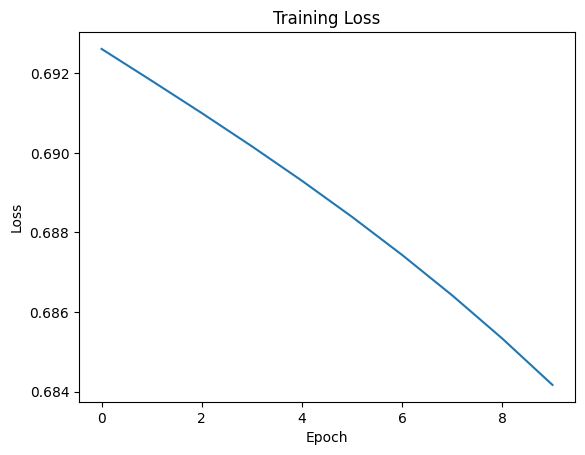

In [10]:
plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [11]:
import pandas as pd

comparison = pd.DataFrame({

    "RNN":[

        "Short-term memory",

        "Affected by vanishing gradients",

        "Simple architecture",

        "Suitable for short sequences"

    ],

    "LSTM":[

        "Long-term memory",

        "Reduces vanishing gradients",

        "Uses memory cells and gates",

        "Suitable for long sequences"

    ]

})

comparison

,RNN,LSTM
0,Short-term memory,Long-term memory
1,Affected by vanishing gradients,Reduces vanishing gradients
2,Simple architecture,Uses memory cells and gates
3,Suitable for short sequences,Suitable for long sequences


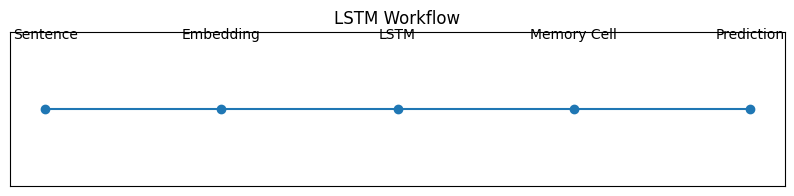

In [12]:
steps = [

    "Sentence",

    "Embedding",

    "LSTM",

    "Memory Cell",

    "Prediction"

]

plt.figure(figsize=(10,2))

plt.plot(

    range(len(steps)),

    [1]*len(steps),

    marker="o"

)

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])

plt.yticks([])

plt.title("LSTM Workflow")

plt.show()